In [16]:
import pandas as pd

url = "https://raw.githubusercontent.com/username/repository/main/dataset.csv"

df = pd.read_csv("https://raw.githubusercontent.com/chowdhurymohammadtushar-sudo/decision_tree/main/diabetes.csv")

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

In [18]:
df.isnull().sum()

df.fillna(df.mode().iloc[0], inplace=True)

In [19]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
cart = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)

params = {
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10]
}

grid_cart = GridSearchCV(
    cart,
    params,
    cv=5,
    scoring='accuracy'
)

grid_cart.fit(X_train,y_train)

best_cart = grid_cart.best_estimator_

print(grid_cart.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [22]:
id3 = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

grid_id3 = GridSearchCV(
    id3,
    params,
    cv=5,
    scoring='accuracy'
)

grid_id3.fit(X_train,y_train)

best_id3 = grid_id3.best_estimator_

print(grid_id3.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [23]:
cart_pred = best_cart.predict(X_test)
id3_pred = best_id3.predict(X_test)

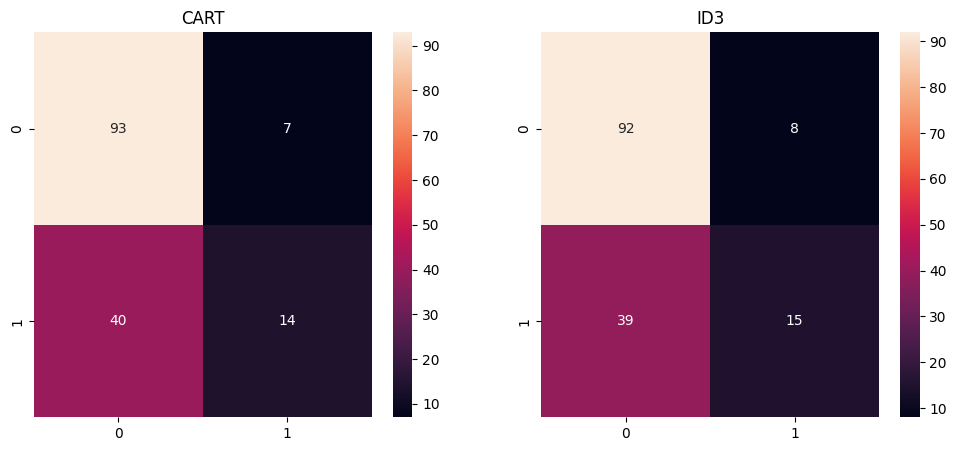

In [24]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.heatmap(
    confusion_matrix(y_test,cart_pred),
    annot=True,
    fmt='d',
    ax=ax[0]
)

ax[0].set_title("CART")

sns.heatmap(
    confusion_matrix(y_test,id3_pred),
    annot=True,
    fmt='d',
    ax=ax[1]
)

ax[1].set_title("ID3")

plt.show()

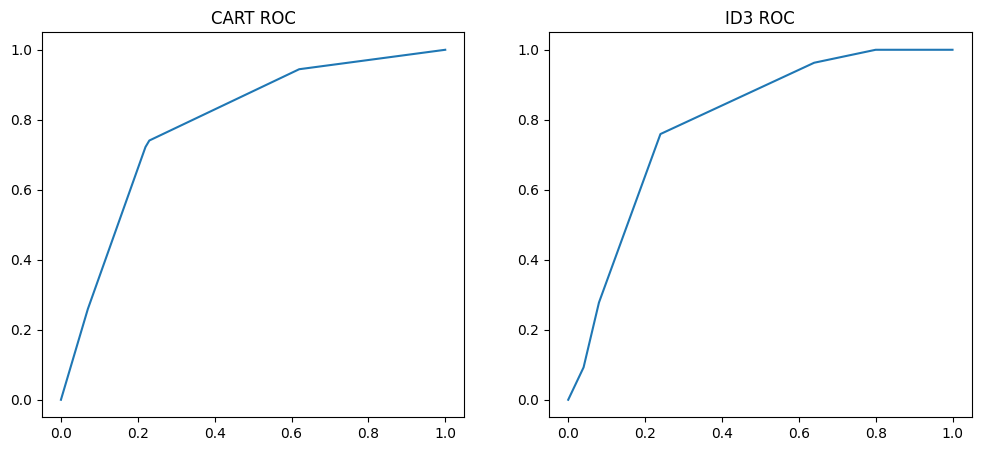

In [25]:
cart_prob = best_cart.predict_proba(X_test)[:,1]
id3_prob = best_id3.predict_proba(X_test)[:,1]

cart_fpr, cart_tpr, _ = roc_curve(y_test, cart_prob)
id3_fpr, id3_tpr, _ = roc_curve(y_test, id3_prob)

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].plot(cart_fpr, cart_tpr)
ax[0].set_title("CART ROC")

ax[1].plot(id3_fpr, id3_tpr)
ax[1].set_title("ID3 ROC")

plt.show()

In [26]:
metrics = pd.DataFrame({
    'Metric':['Accuracy','Precision','Recall','F1','AUC'],
    'CART':[
        accuracy_score(y_test,cart_pred),
        precision_score(y_test,cart_pred),
        recall_score(y_test,cart_pred),
        f1_score(y_test,cart_pred),
        roc_auc_score(y_test,cart_prob)
    ],
    'ID3':[
        accuracy_score(y_test,id3_pred),
        precision_score(y_test,id3_pred),
        recall_score(y_test,id3_pred),
        f1_score(y_test,id3_pred),
        roc_auc_score(y_test,id3_prob)
    ]
})

metrics

,Metric,CART,ID3
0,Accuracy,0.694805,0.694805
1,Precision,0.666667,0.652174
2,Recall,0.259259,0.277778
3,F1,0.373333,0.389610
4,AUC,0.788056,0.793704


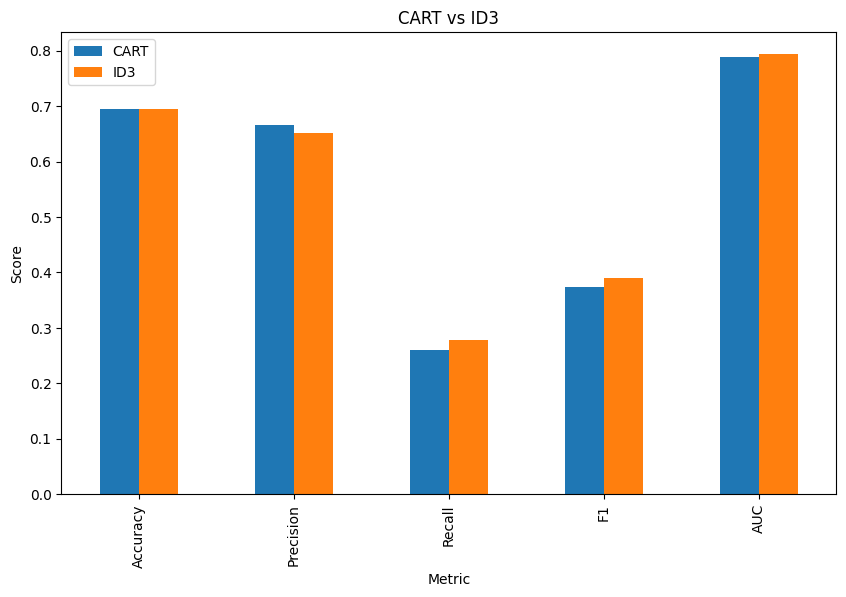

In [27]:
metrics.set_index('Metric').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title("CART vs ID3")
plt.ylabel("Score")
plt.show()

In [28]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.2,
    random_state=42
)

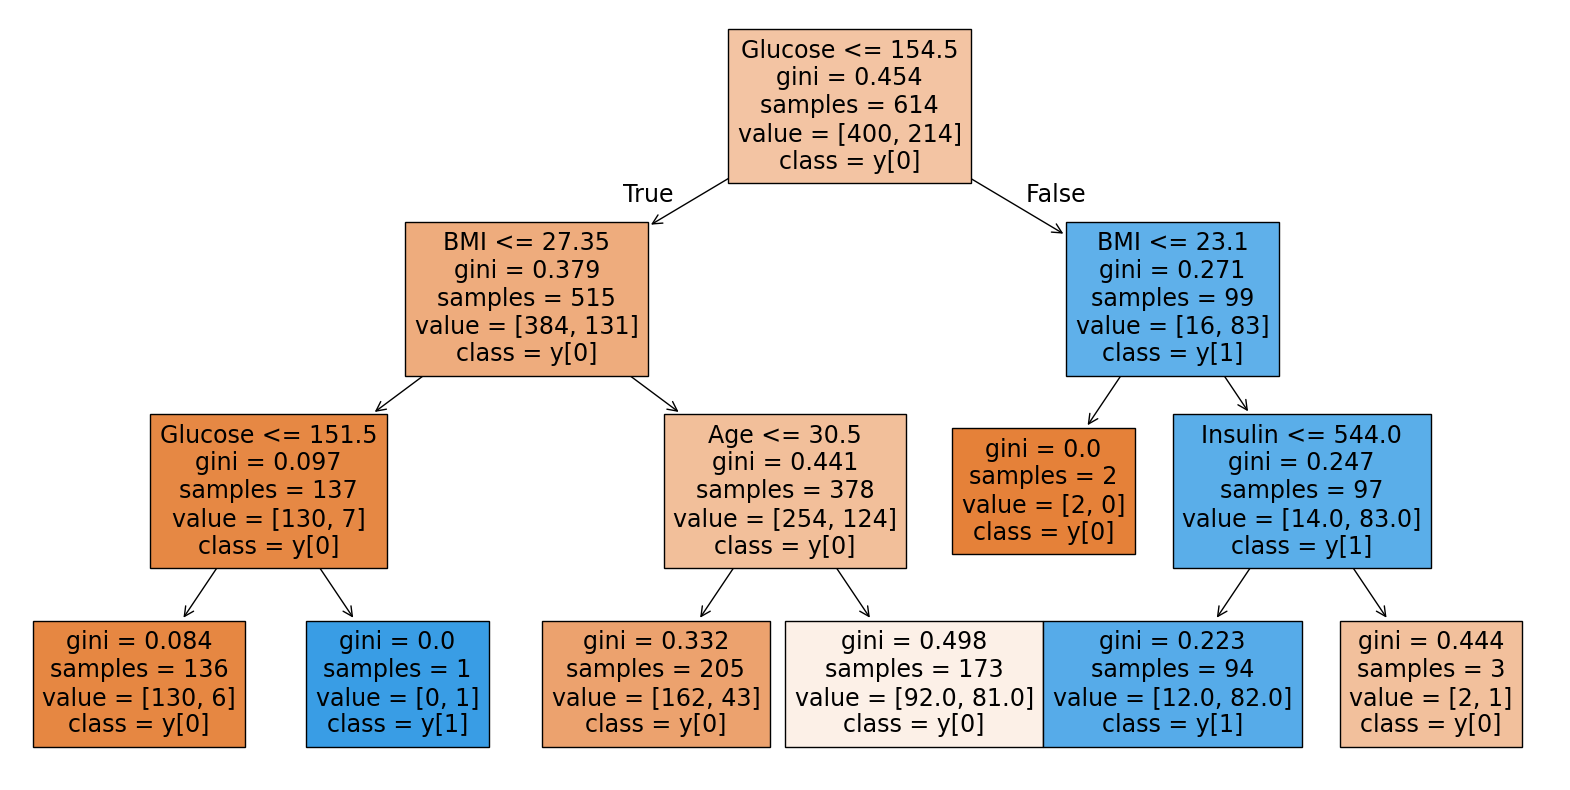

In [29]:
plt.figure(figsize=(20,10))

plot_tree(
    best_cart,
    filled=True,
    feature_names=X.columns,
    class_names=True
)

plt.show()